#1. Importing necessary libaries

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#2. Data loading using panda dataframe

In [29]:
import pandas as pd

# Load the dataset from the sample_data directory
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/placement_predict_50k Dataset(in).csv')

# Display the first 5 rows of the DataFrame
#display(df.head())

In [30]:
#display(df.tail())


In [31]:
#df.info()

#3. Analysing missing values

In [32]:
# Count missing values for each column
missing_values_count = df.isnull().sum()

# Display the counts of missing values
display(missing_values_count)

,0
StudentID,0
Gender,0
City,0
CollegeTier,0
Stream,0
Specialisation,0
Hostel,0
HistoryOfBacklogs,0
SGPA_Sem1,0
SGPA_Sem2,0


In [33]:
missing_values_count = missing_values_count[missing_values_count > 0]
missing_values_count

,0
Workshops,4488
AptitudeTestScore,4029
SoftSkillsRating,3526
CodingTestScore,2976
MockInterviewScore,4957


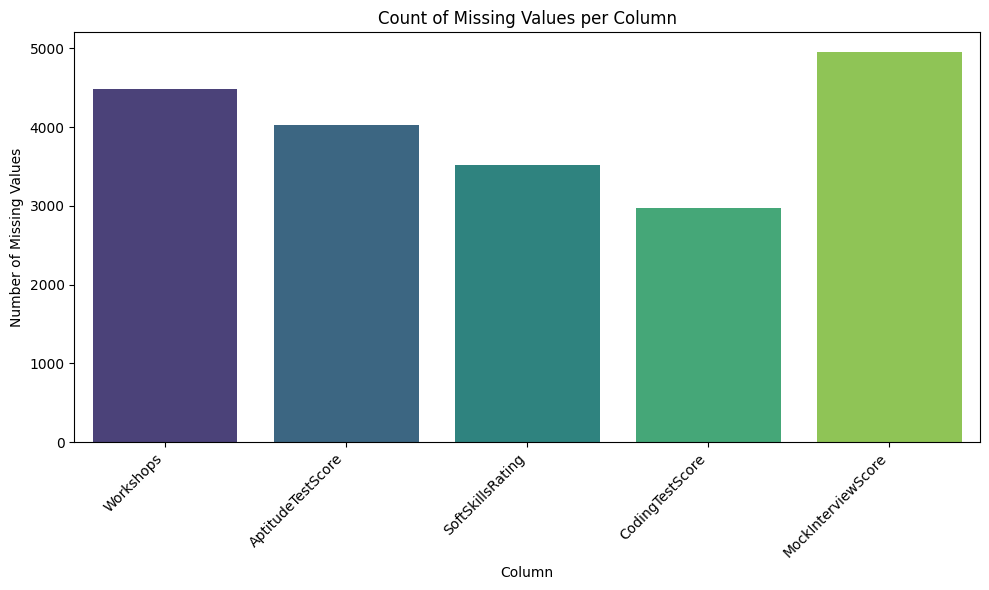

In [34]:
# Plotting the bar chart for missing values using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values_count.index, y=missing_values_count.values, hue=missing_values_count.index, palette='viridis', legend=False)
plt.title('Count of Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bar Chart using MatplotliB

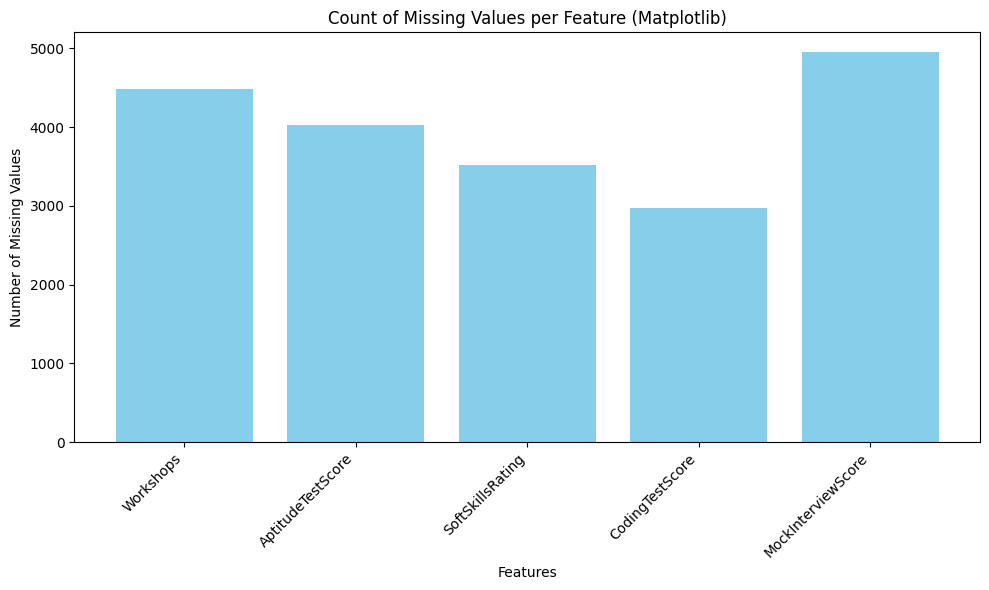

In [35]:
#import matplotlib.pyplot as plt

# Plotting the bar chart for missing values using matplotlib
plt.figure(figsize=(10, 6))
plt.bar(x=missing_values_count.index, height=missing_values_count.values, color='skyblue')
plt.title('Count of Missing Values per Feature (Matplotlib)')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#4.Identifying Numeric Features

In [36]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

print("Numeric Features:")
for col in numeric_cols:
    print(f"- {col}")

# Optionally, display the numeric columns and their data types
# display(df[numeric_cols].head())
# display(df[numeric_cols].info())

Numeric Features:
- StudentID
- SGPA_Sem1
- SGPA_Sem2
- SGPA_Sem3
- SGPA_Sem4
- SGPA_Sem5
- SGPA_Sem6
- SGPA_Sem7
- SGPA_Sem8
- CGPA
- AttendancePercent
- Internships
- Projects
- Workshops
- Certifications
- Publications
- AptitudeTestScore
- SoftSkillsRating
- CodingTestScore
- MockInterviewScore
- ExtraCurricular
- PlacementStatus
- IsAnomaly


In [37]:
df.describe()

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,45512.000000,50000.000000,50000.000000,45971.000000,46474.000000,47024.000000,45043.00000,50000.000000,50000.000000,50000.000000
mean,25000.500000,7.210583,7.222243,7.235398,7.247290,7.258639,7.274511,7.282720,7.293704,7.246154,...,1.804469,1.931420,0.735460,68.859261,3.154211,57.411273,55.40853,0.533000,0.657120,0.035000
std,14433.901067,1.517846,1.532008,1.551632,1.570629,1.587829,1.603261,1.621605,1.638112,1.615686,...,1.036193,1.175391,0.717167,15.365230,0.981333,20.979679,17.52218,0.498915,0.474677,0.183782
min,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,15.90000,0.000000,0.000000,0.000000
25%,12500.750000,6.090000,6.090000,6.080000,6.070000,6.070000,6.080000,6.060000,6.060000,6.040000,...,1.000000,1.000000,0.000000,58.500000,2.400000,45.900000,44.20000,0.000000,0.000000,0.000000
50%,25000.500000,7.190000,7.210000,7.220000,7.240000,7.260000,7.280000,7.300000,7.310000,7.250000,...,2.000000,2.000000,1.000000,69.900000,3.200000,57.700000,54.70000,1.000000,1.000000,0.000000
75%,37500.250000,8.340000,8.360000,8.400000,8.430000,8.460000,8.500000,8.520000,8.560000,8.480000,...,3.000000,3.000000,1.000000,79.700000,3.900000,73.300000,69.20000,1.000000,1.000000,0.000000
max,50000.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,4.000000,5.000000,3.000000,100.000000,5.000000,100.000000,100.00000,1.000000,1.000000,1.000000


In [38]:
columns_to_exclude = ['StudentID', 'PlacementStatus', 'IsAnomaly']
df.drop(columns=columns_to_exclude).describe()

,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,45512.000000,50000.000000,50000.000000,45971.000000,46474.000000,47024.000000,45043.00000,50000.000000
mean,7.210583,7.222243,7.235398,7.247290,7.258639,7.274511,7.282720,7.293704,7.246154,76.709863,1.127740,2.109520,1.804469,1.931420,0.735460,68.859261,3.154211,57.411273,55.40853,0.533000
std,1.517846,1.532008,1.551632,1.570629,1.587829,1.603261,1.621605,1.638112,1.615686,12.474386,0.813631,1.207607,1.036193,1.175391,0.717167,15.365230,0.981333,20.979679,17.52218,0.498915
min,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,15.90000,0.000000
25%,6.090000,6.090000,6.080000,6.070000,6.070000,6.080000,6.060000,6.060000,6.040000,67.600000,1.000000,1.000000,1.000000,1.000000,0.000000,58.500000,2.400000,45.900000,44.20000,0.000000
50%,7.190000,7.210000,7.220000,7.240000,7.260000,7.280000,7.300000,7.310000,7.250000,77.200000,1.000000,2.000000,2.000000,2.000000,1.000000,69.900000,3.200000,57.700000,54.70000,1.000000
75%,8.340000,8.360000,8.400000,8.430000,8.460000,8.500000,8.520000,8.560000,8.480000,85.900000,2.000000,3.000000,3.000000,3.000000,1.000000,79.700000,3.900000,73.300000,69.20000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,3.000000,5.000000,4.000000,5.000000,3.000000,100.000000,5.000000,100.000000,100.00000,1.000000


### 4. Outlier Analysis for Numeric Features

We will use box plots to visualize the distribution of each numeric feature and identify potential outliers. We'll exclude `StudentID`, `PlacementStatus`, and `IsAnomaly` as they are not suitable for this type of analysis.

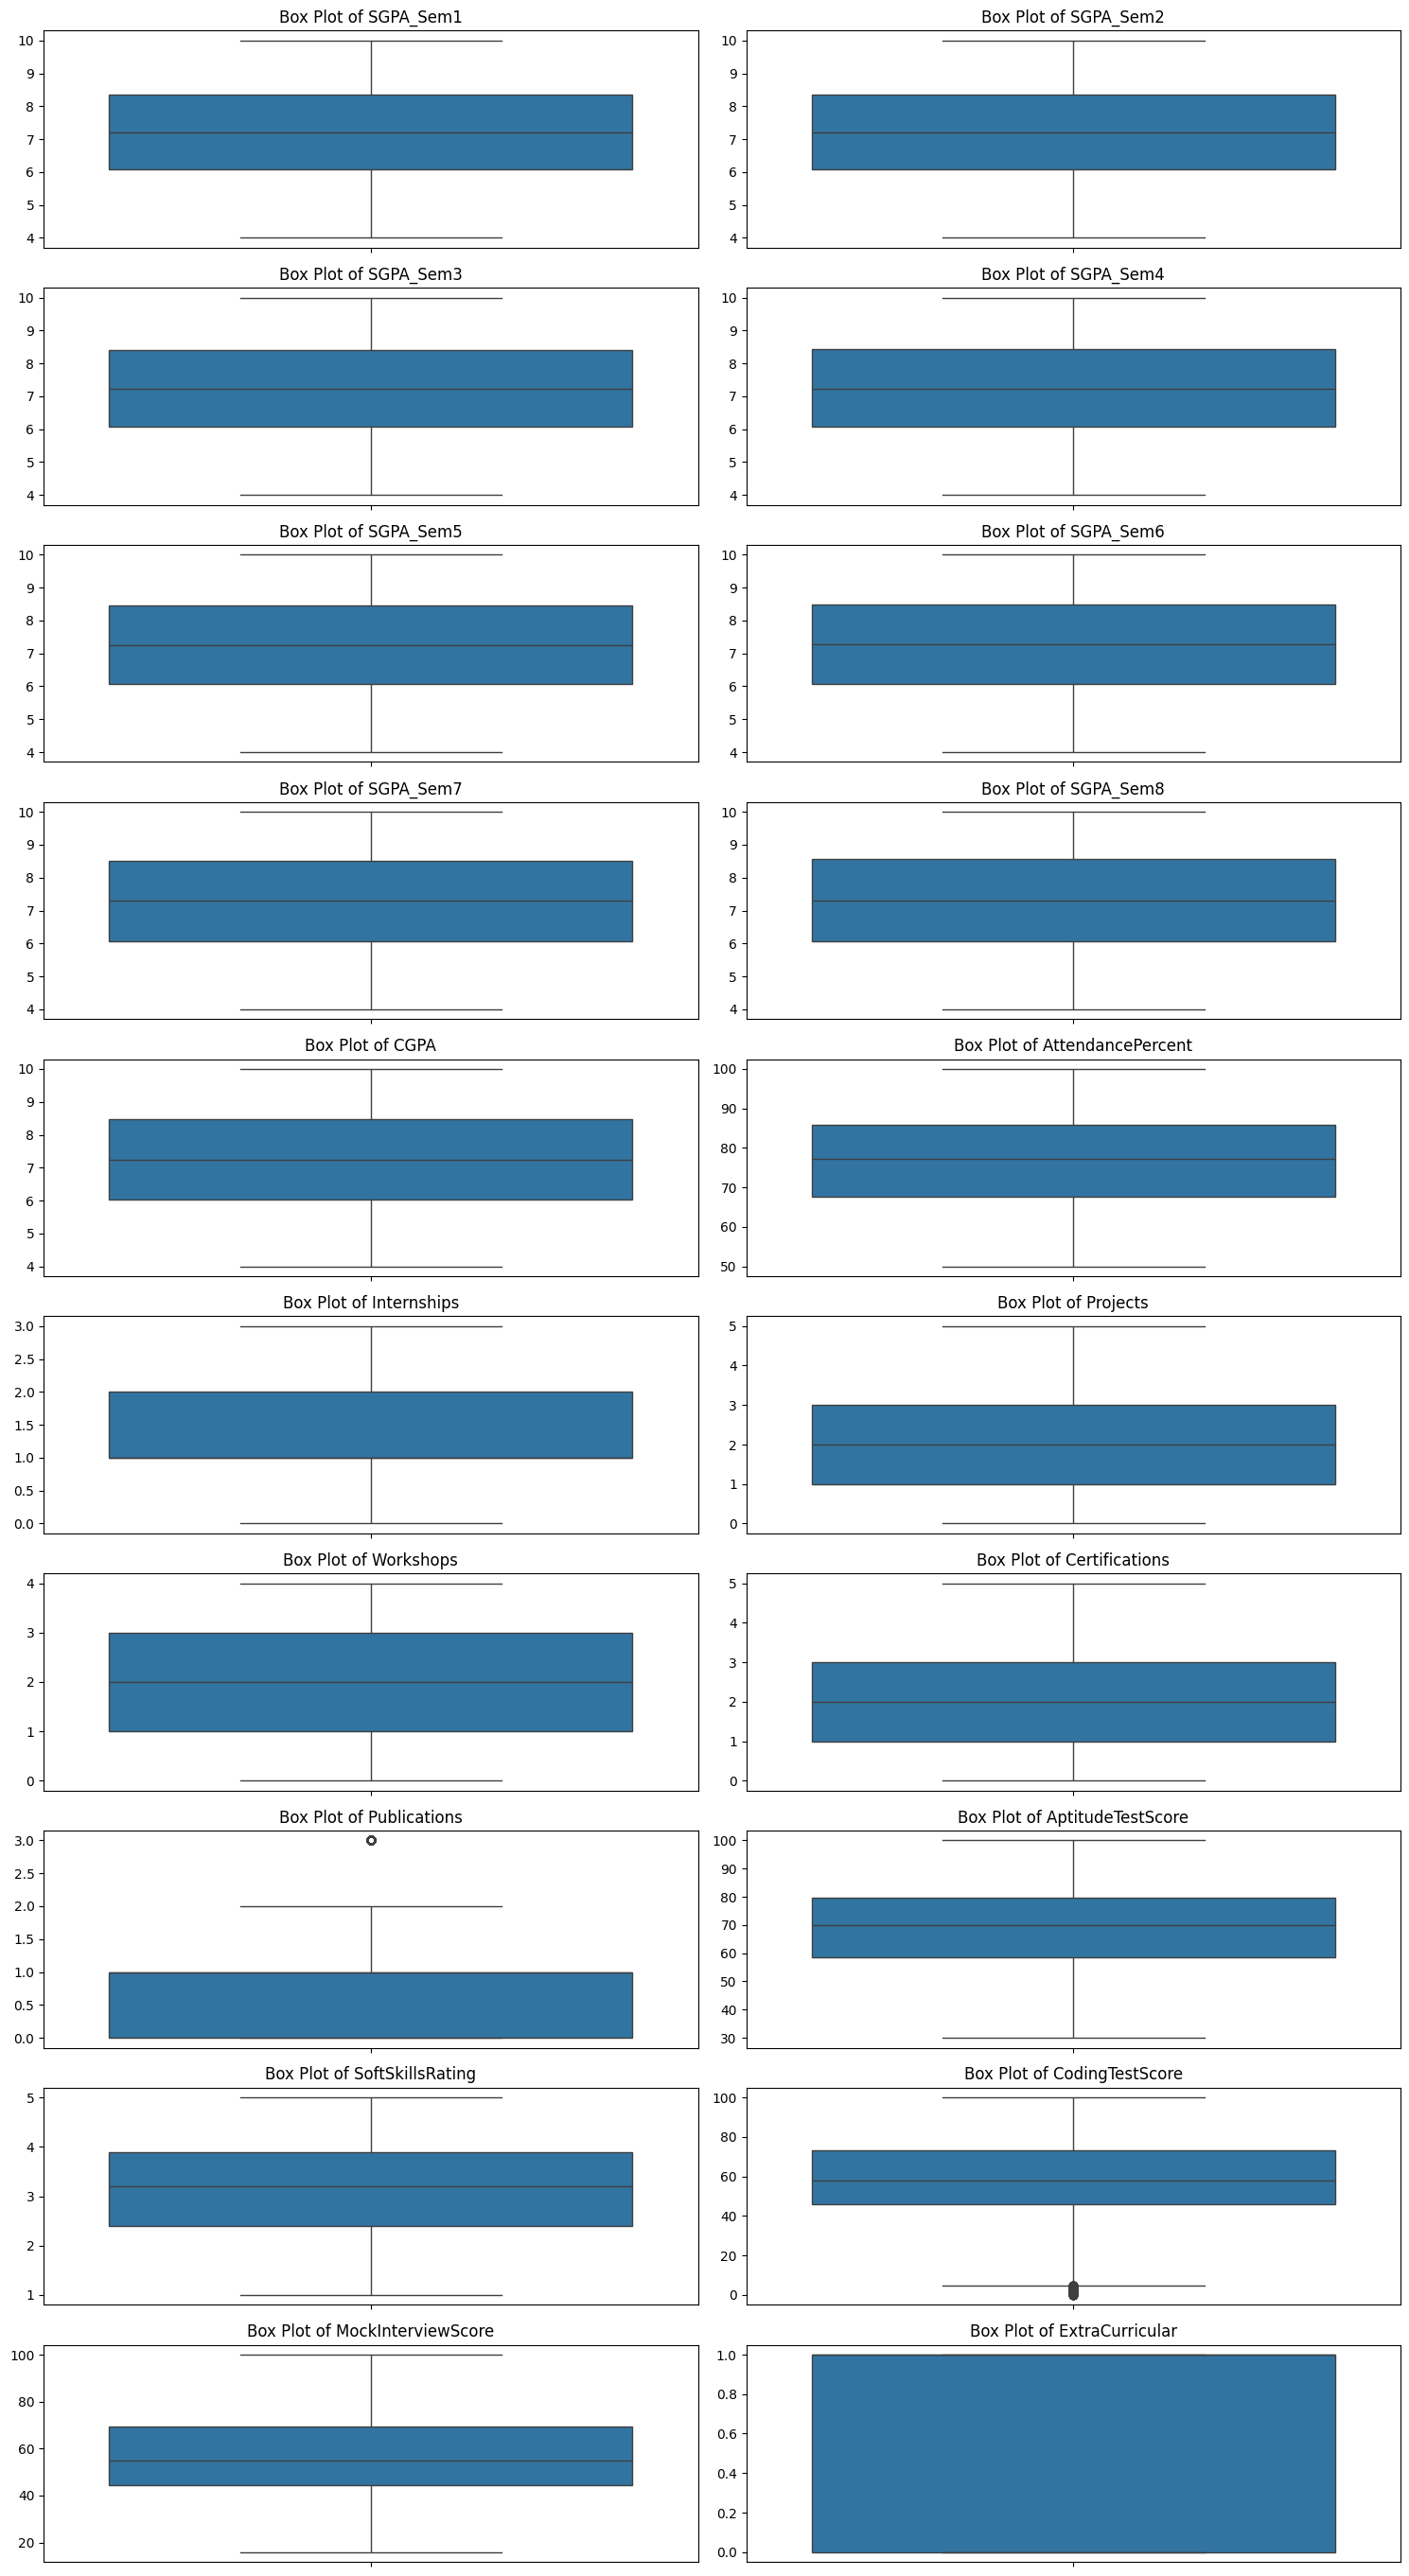

In [39]:
numeric_cols_for_outliers = [col for col in numeric_cols if col not in ['StudentID', 'PlacementStatus', 'IsAnomaly']]

# Set up the figure size for better visualization
plt.figure(figsize=(15, 30)) # Adjust figure size as needed

for i, column in enumerate(numeric_cols_for_outliers, 1):
    plt.subplot(int(len(numeric_cols_for_outliers)/2) + 1, 2, i) # Arrange plots in a grid
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

### 5. Correlation Analysis of Numeric Features

To understand the relationships between different numeric features, we'll compute and visualize the correlation matrix. This will help us identify features that are highly correlated, which can be useful for feature selection or understanding dependencies.

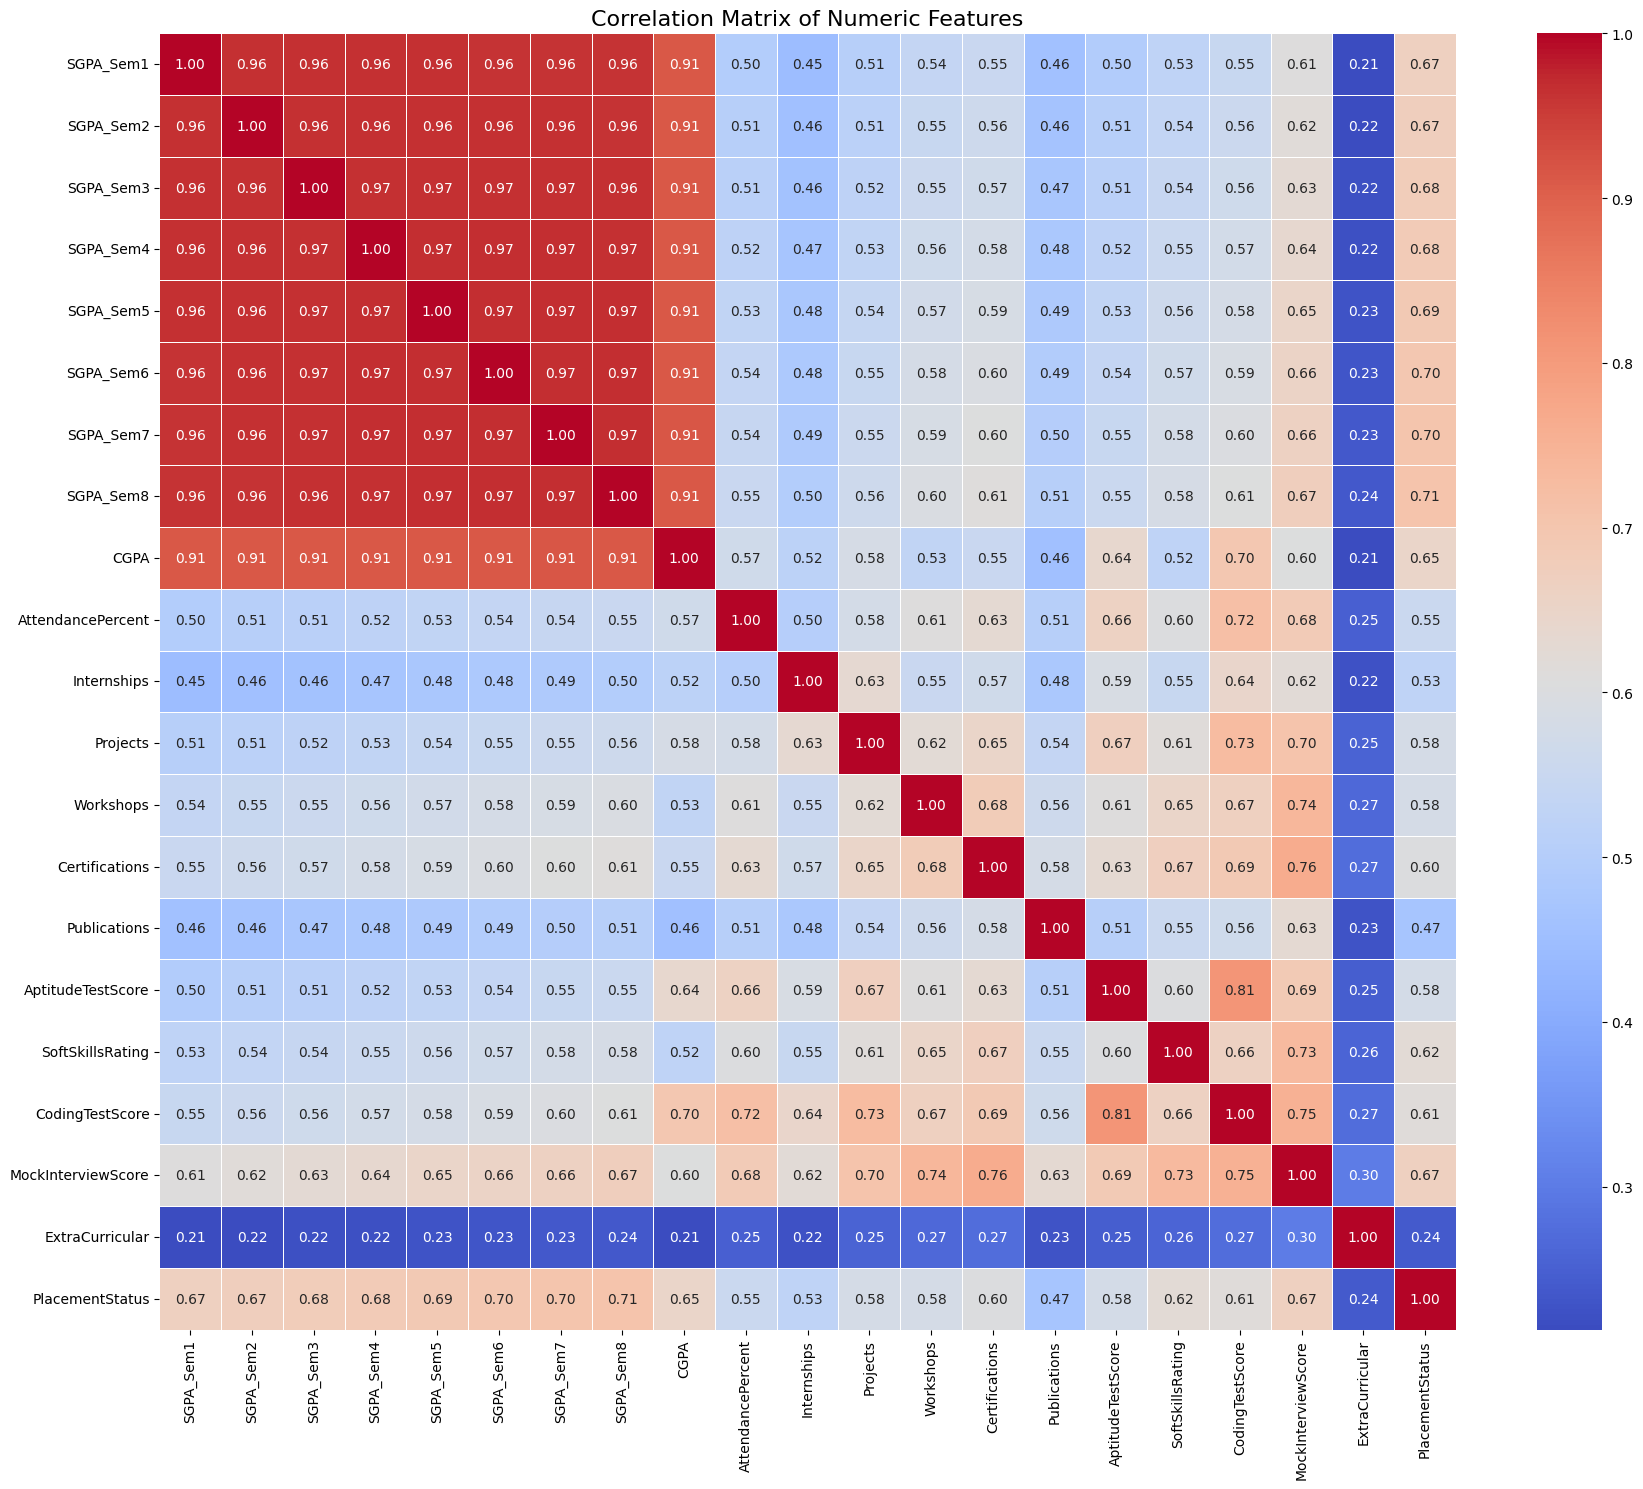

In [40]:
# Calculate the correlation matrix for the numeric features (excluding StudentID, IsAnomaly)
numeric_cols_for_outliers = [col for col in numeric_cols if col not in ['StudentID', 'IsAnomaly']]
correlation_matrix = df[numeric_cols_for_outliers].corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 15))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix,
            annot=True,    # Show the correlation values on the heatmap
            cmap='coolwarm', # Choose a diverging colormap
            fmt=".2f",     # Format annotations to two decimal places
            linewidths=.5) # Add lines between cells for better readability

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 6. Imputing Missing Values with Mean

To handle the missing values identified earlier, we will impute them with the mean of their respective columns. This approach is suitable for numerical data and helps maintain the overall distribution characteristics of the features.

In [41]:
import pandas as pd

# Columns with missing values (identified previously)
missing_cols_to_impute = ['Workshops', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']

for col in missing_cols_to_impute:
    if col in df.columns:
        mean_value = df[col].mean()
        df[col] = df[col].fillna(mean_value)
        print(f"Missing values in '{col}' imputed with mean: {mean_value:.2f}")

# Verify that there are no more missing values in these columns
print("\nMissing values after imputation:")
display(df[missing_cols_to_impute].isnull().sum())

Missing values in 'Workshops' imputed with mean: 1.80
Missing values in 'AptitudeTestScore' imputed with mean: 68.86
Missing values in 'SoftSkillsRating' imputed with mean: 3.15
Missing values in 'CodingTestScore' imputed with mean: 57.41
Missing values in 'MockInterviewScore' imputed with mean: 55.41

Missing values after imputation:


,0
Workshops,0
AptitudeTestScore,0
SoftSkillsRating,0
CodingTestScore,0
MockInterviewScore,0


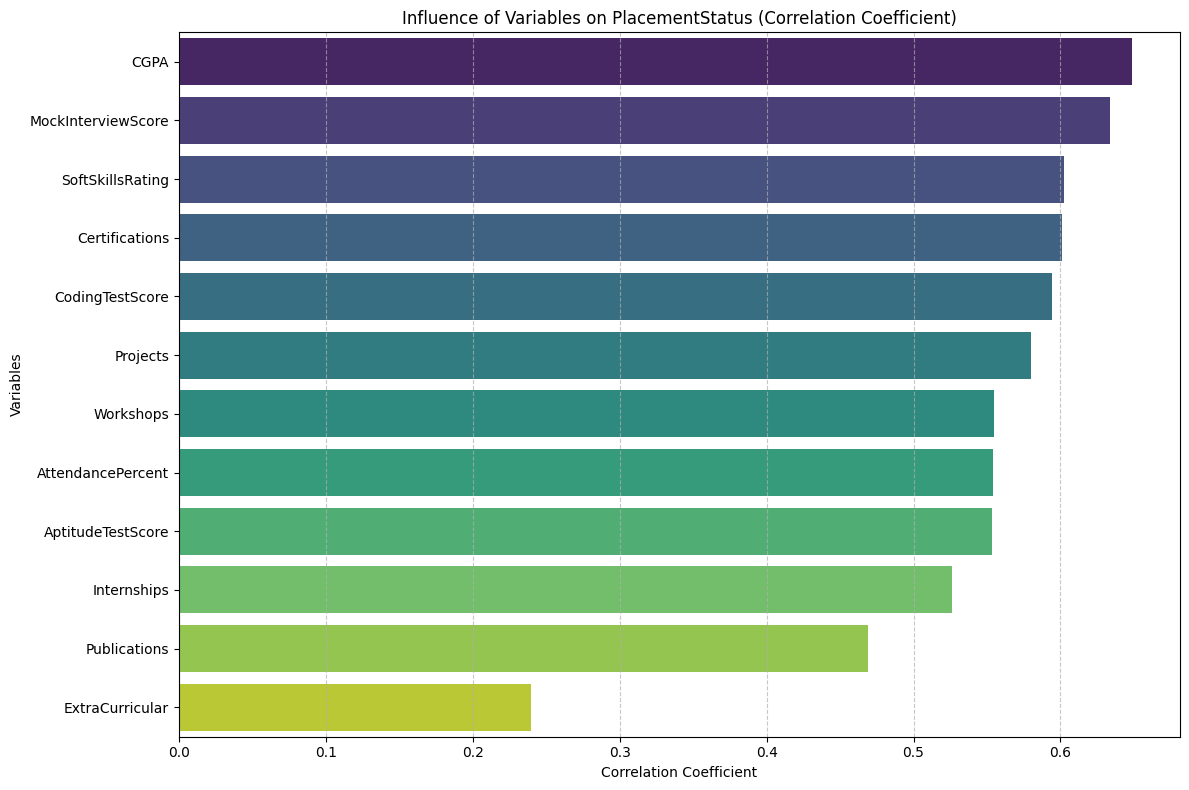

Correlation of independent variables with PlacementStatus:


,PlacementStatus
CGPA,0.648926
MockInterviewScore,0.633843
SoftSkillsRating,0.602174
Certifications,0.601315
CodingTestScore,0.594212
Projects,0.580122
Workshops,0.554889
AttendancePercent,0.554024
AptitudeTestScore,0.553582
Internships,0.526197


In [42]:
independent_variables = [
    'CGPA',
    'AttendancePercent',
    'Internships',
    'Projects',
    'Workshops',
    'Certifications',
    'Publications',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'CodingTestScore',
    'MockInterviewScore',
    'ExtraCurricular'
]
target_variable = 'PlacementStatus'

# Calculate the correlation of each independent variable with the target variable
correlations = df[independent_variables + [target_variable]].corr()[target_variable].drop(target_variable)

# Sort correlations for better visualization
correlations = correlations.sort_values(ascending=False)

# Plotting the influence of variables on PlacementStatus
plt.figure(figsize=(12, 8))
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.index, palette='viridis', legend=False)
plt.title('Influence of Variables on PlacementStatus (Correlation Coefficient)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Correlation of independent variables with PlacementStatus:")
display(correlations)

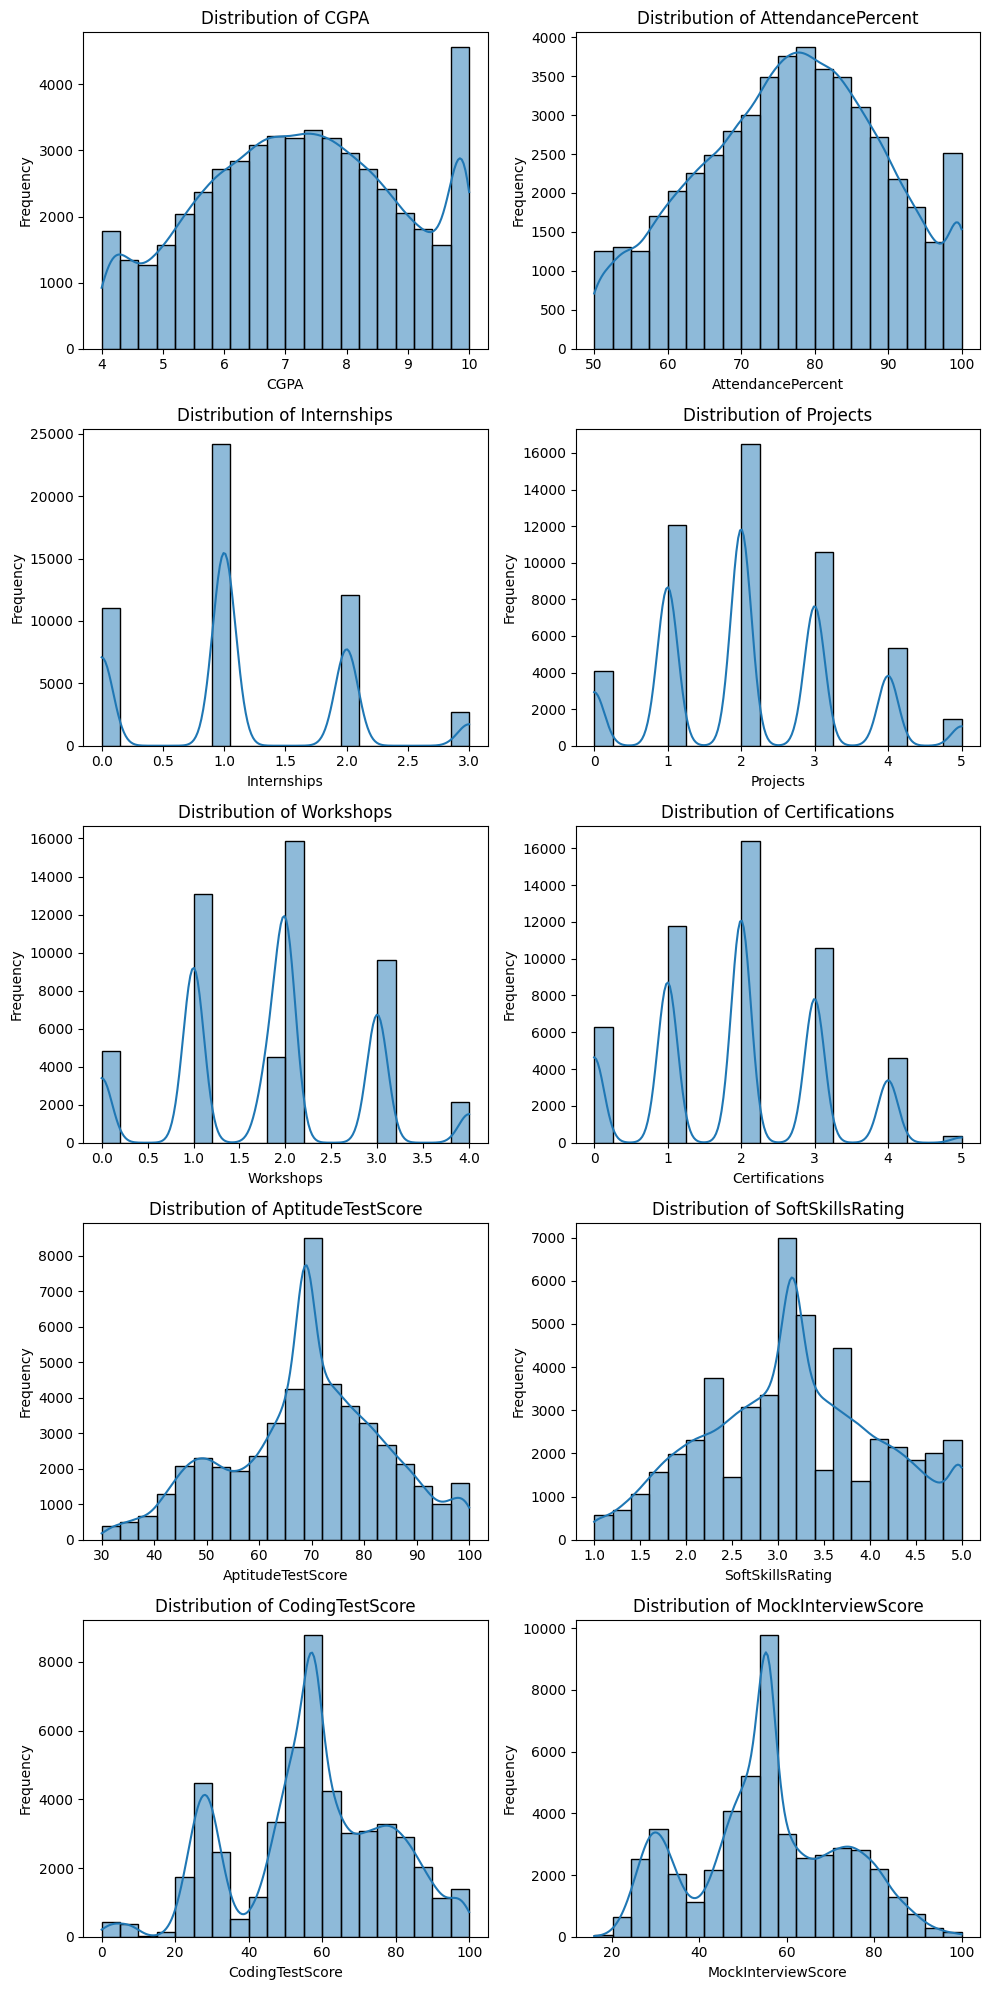

In [43]:
distribution_variables = [
    'CGPA',
    'AttendancePercent',
    'Internships',
    'Projects',
    'Workshops',
    'Certifications',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'CodingTestScore',
    'MockInterviewScore'
]

# Determine the number of rows and columns for the subplots
n_vars = len(distribution_variables)
n_cols = 2 # You can adjust the number of columns as needed
n_rows = (n_vars + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(distribution_variables):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 7. Standardizing Numeric Features using Z-score

We will standardize `AptitudeTestScore`, `SoftSkillsRating`, `CodingTestScore`, and `MockInterviewScore` using the Z-score method. Z-score standardization transforms data to have a mean of 0 and a standard deviation of 1, which is useful for algorithms that assume normally distributed data or are sensitive to feature scales. After standardization, we will visualize the distributions again.

In [44]:
from sklearn.preprocessing import StandardScaler

variables_to_standardize = [
    'AptitudeTestScore',
    'SoftSkillsRating',
    'CodingTestScore',
    'MockInterviewScore'
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the selected columns and create new columns for the standardized values
for col in variables_to_standardize:
    df[f'Standardized_{col}'] = scaler.fit_transform(df[[col]])
    print(f"Standardized '{col}' and created 'Standardized_{col}'.")

print("\nFirst 5 rows with new standardized columns:")
display(df[[f'Standardized_{col}' for col in variables_to_standardize]].head())

Standardized 'AptitudeTestScore' and created 'Standardized_AptitudeTestScore'.
Standardized 'SoftSkillsRating' and created 'Standardized_SoftSkillsRating'.
Standardized 'CodingTestScore' and created 'Standardized_CodingTestScore'.
Standardized 'MockInterviewScore' and created 'Standardized_MockInterviewScore'.

First 5 rows with new standardized columns:


,Standardized_AptitudeTestScore,Standardized_SoftSkillsRating,Standardized_CodingTestScore,Standardized_MockInterviewScore
0,-0.146559,-1.008585,-0.393761,-0.457498
1,-1.402244,-0.797188,-1.509485,-1.780348
2,0.335352,-0.374395,0.505700,-0.836314
3,0.063852,-0.480093,0.466379,-0.445472
4,0.287839,-1.114283,0.702303,0.378303


### 8. Visualizing Distributions of Standardized Features

Now, let's visualize the distributions of the newly standardized features to observe the effect of Z-score scaling.

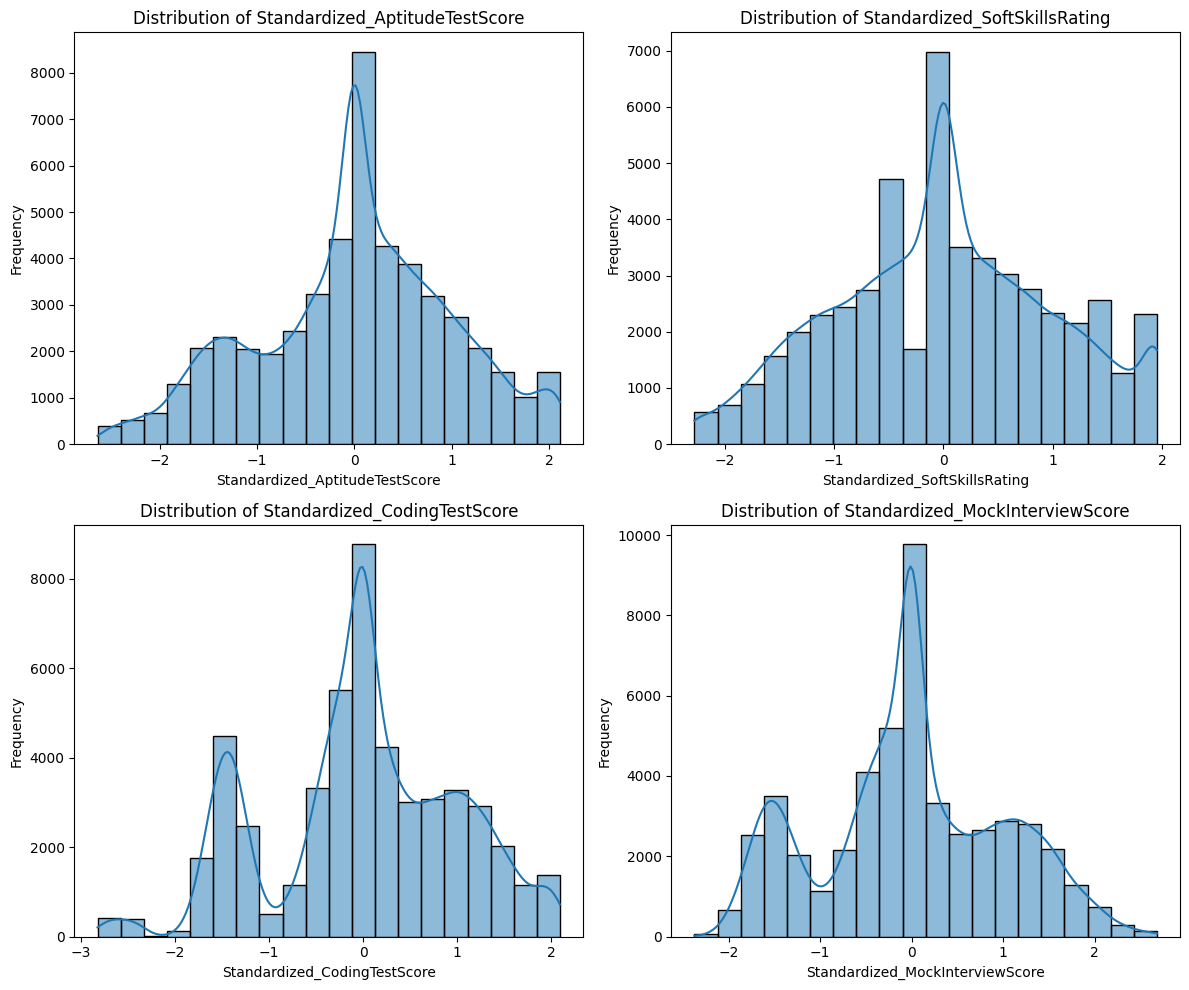

In [45]:
standardized_distribution_variables = [
    'Standardized_AptitudeTestScore',
    'Standardized_SoftSkillsRating',
    'Standardized_CodingTestScore',
    'Standardized_MockInterviewScore'
]

# Determine the number of rows and columns for the subplots
n_vars_std = len(standardized_distribution_variables)
n_cols_std = 2 # You can adjust the number of columns as needed
n_rows_std = (n_vars_std + n_cols_std - 1) // n_cols_std # Calculate rows needed

plt.figure(figsize=(n_cols_std * 6, n_rows_std * 5))

for i, col in enumerate(standardized_distribution_variables):
    plt.subplot(n_rows_std, n_cols_std, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Boxplots for Key Features vs. Placement Status

These boxplots visualize the distribution of various key features (CGPA, Internships, etc.) for students based on their `PlacementStatus`. This helps in observing if there are noticeable differences in these feature distributions between placed and unplaced students, which can indicate their influence on placement outcomes.

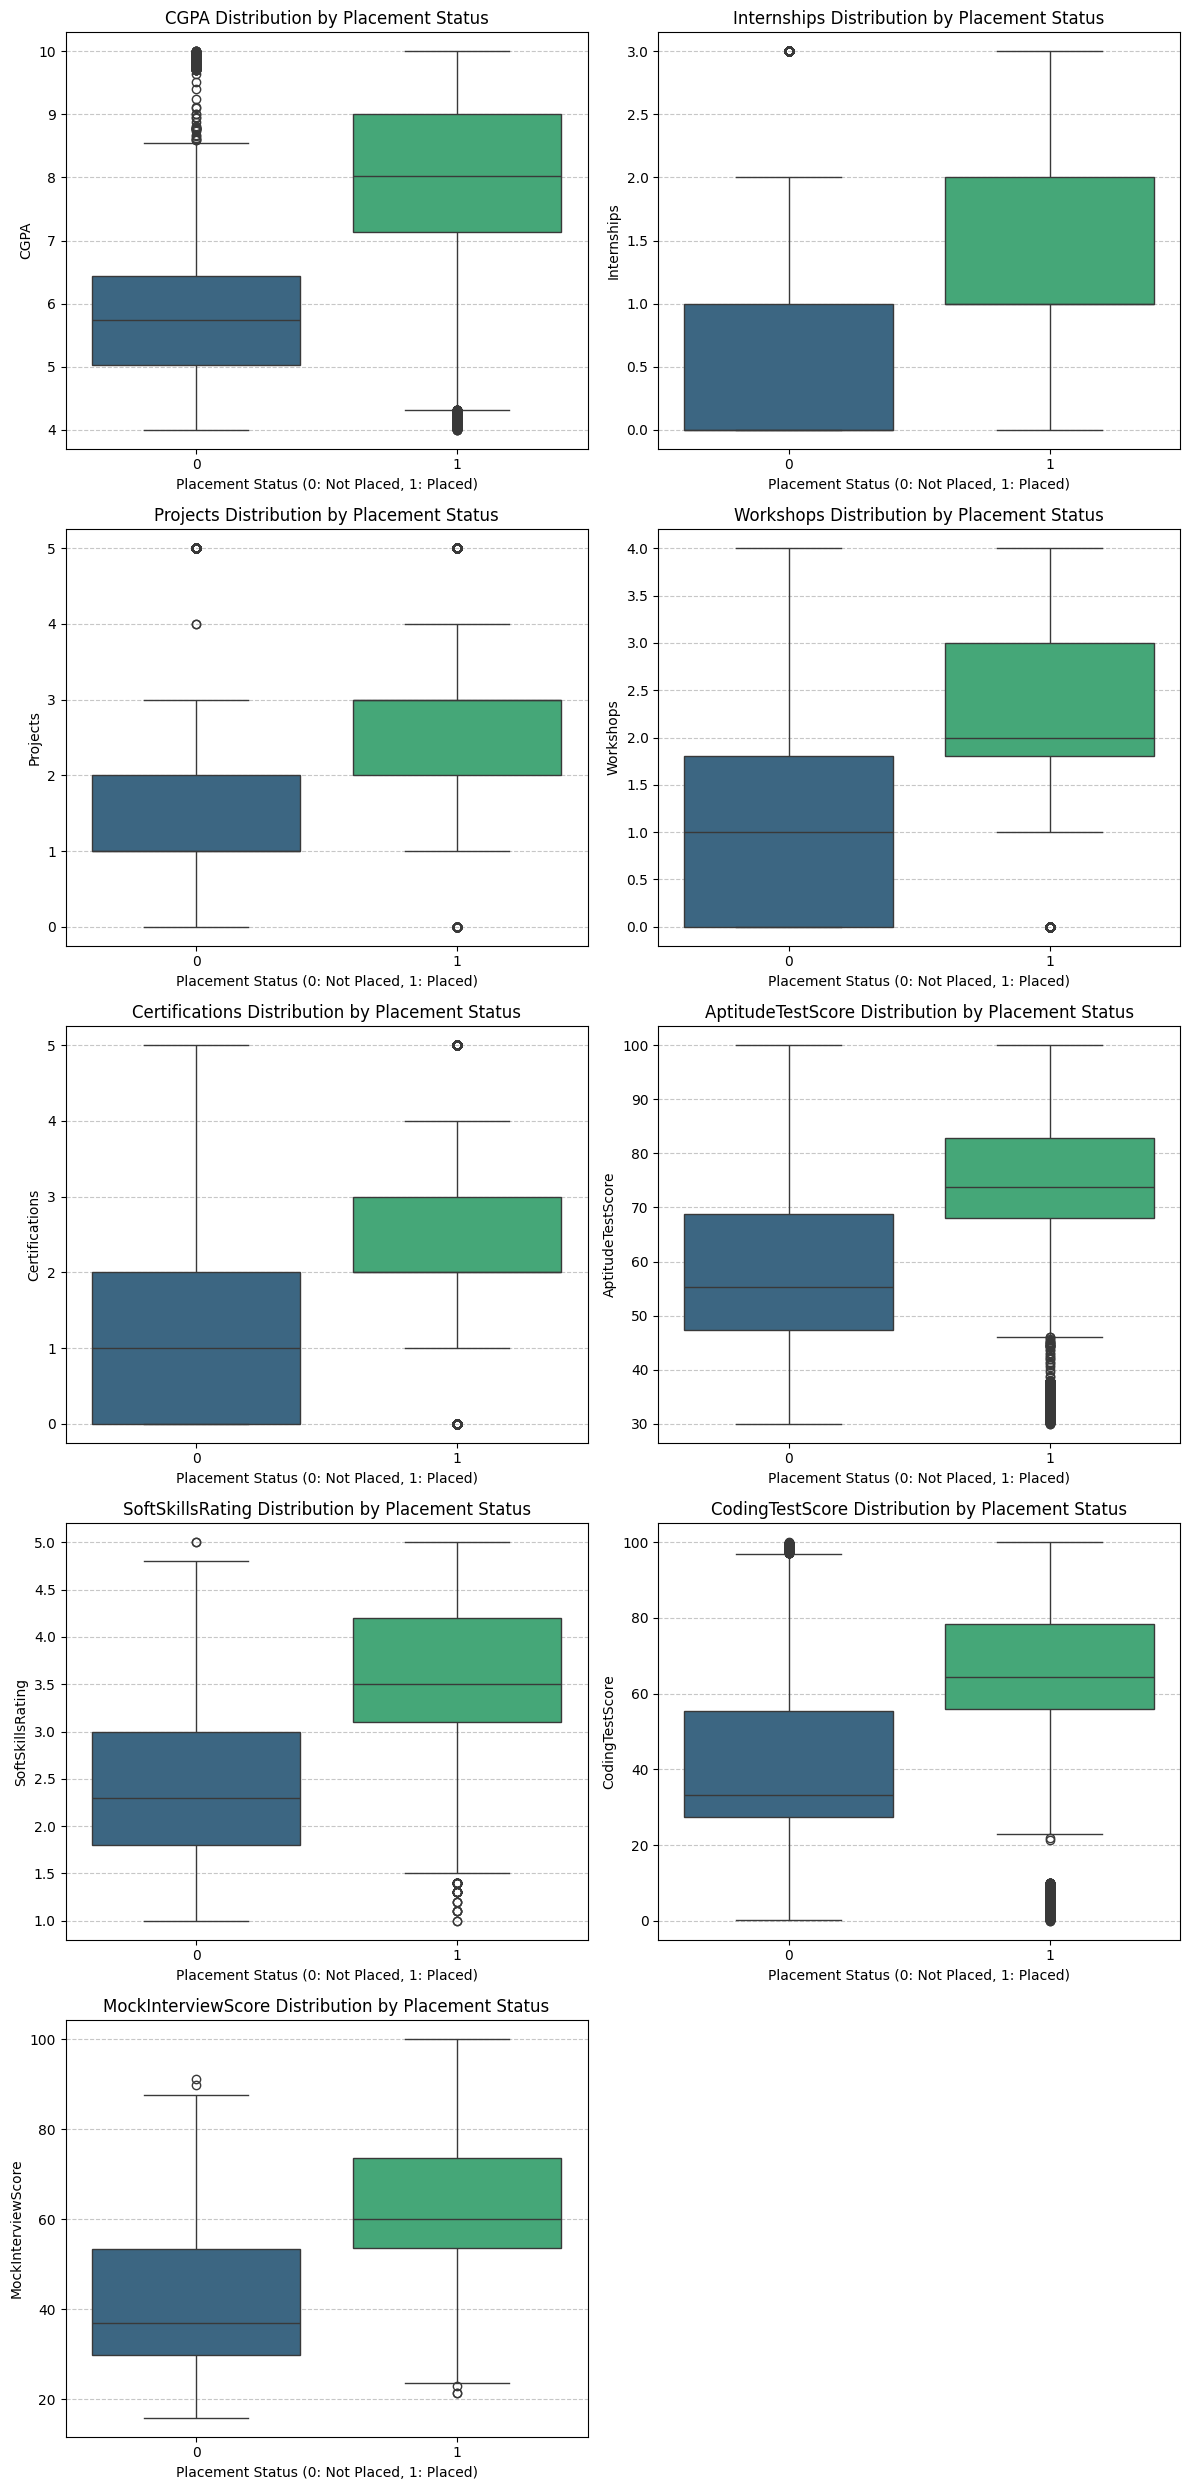

In [46]:
variables_for_boxplot = [
    'CGPA',
    'Internships',
    'Projects',
    'Workshops',
    'Certifications',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'CodingTestScore',
    'MockInterviewScore'
]

n_vars_bp = len(variables_for_boxplot)
n_cols_bp = 2 # You can adjust the number of columns as needed
n_rows_bp = (n_vars_bp + n_cols_bp - 1) // n_cols_bp # Calculate rows needed

plt.figure(figsize=(n_cols_bp * 6, n_rows_bp * 5)) # Adjust figure size dynamically

for i, col in enumerate(variables_for_boxplot):
    plt.subplot(n_rows_bp, n_cols_bp, i + 1)
    sns.boxplot(x='PlacementStatus', y=col, data=df, hue='PlacementStatus', palette='viridis', legend=False)
    plt.title(f'{col} Distribution by Placement Status')
    plt.xlabel('Placement Status (0: Not Placed, 1: Placed)')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Countplot for Gender vs. Placement Status

This countplot visualizes the distribution of `PlacementStatus` across different `Gender` categories, helping to identify any disparities in placement rates between male and female students.

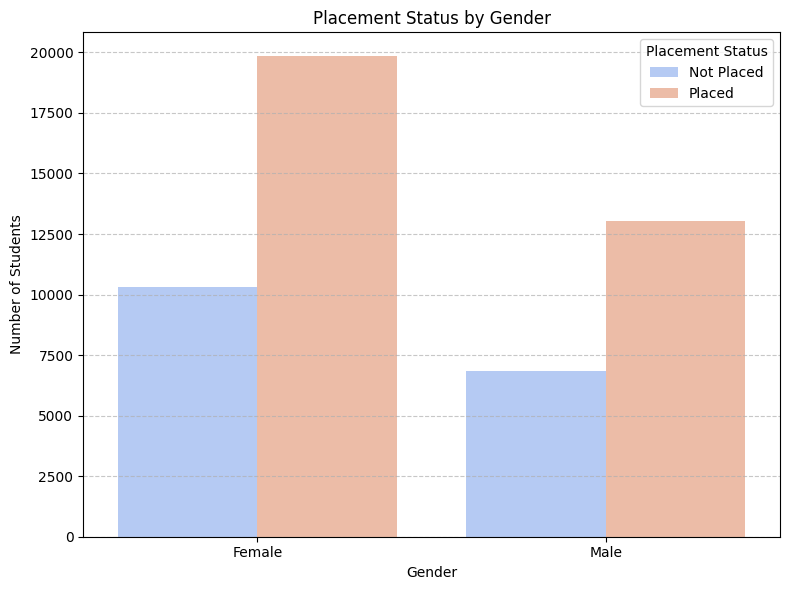

In [47]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', hue='PlacementStatus', data=df, palette='coolwarm')
plt.title('Placement Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male']) # Assuming 0 for Female, 1 for Male or similar encoding
plt.legend(title='Placement Status', labels=['Not Placed', 'Placed'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

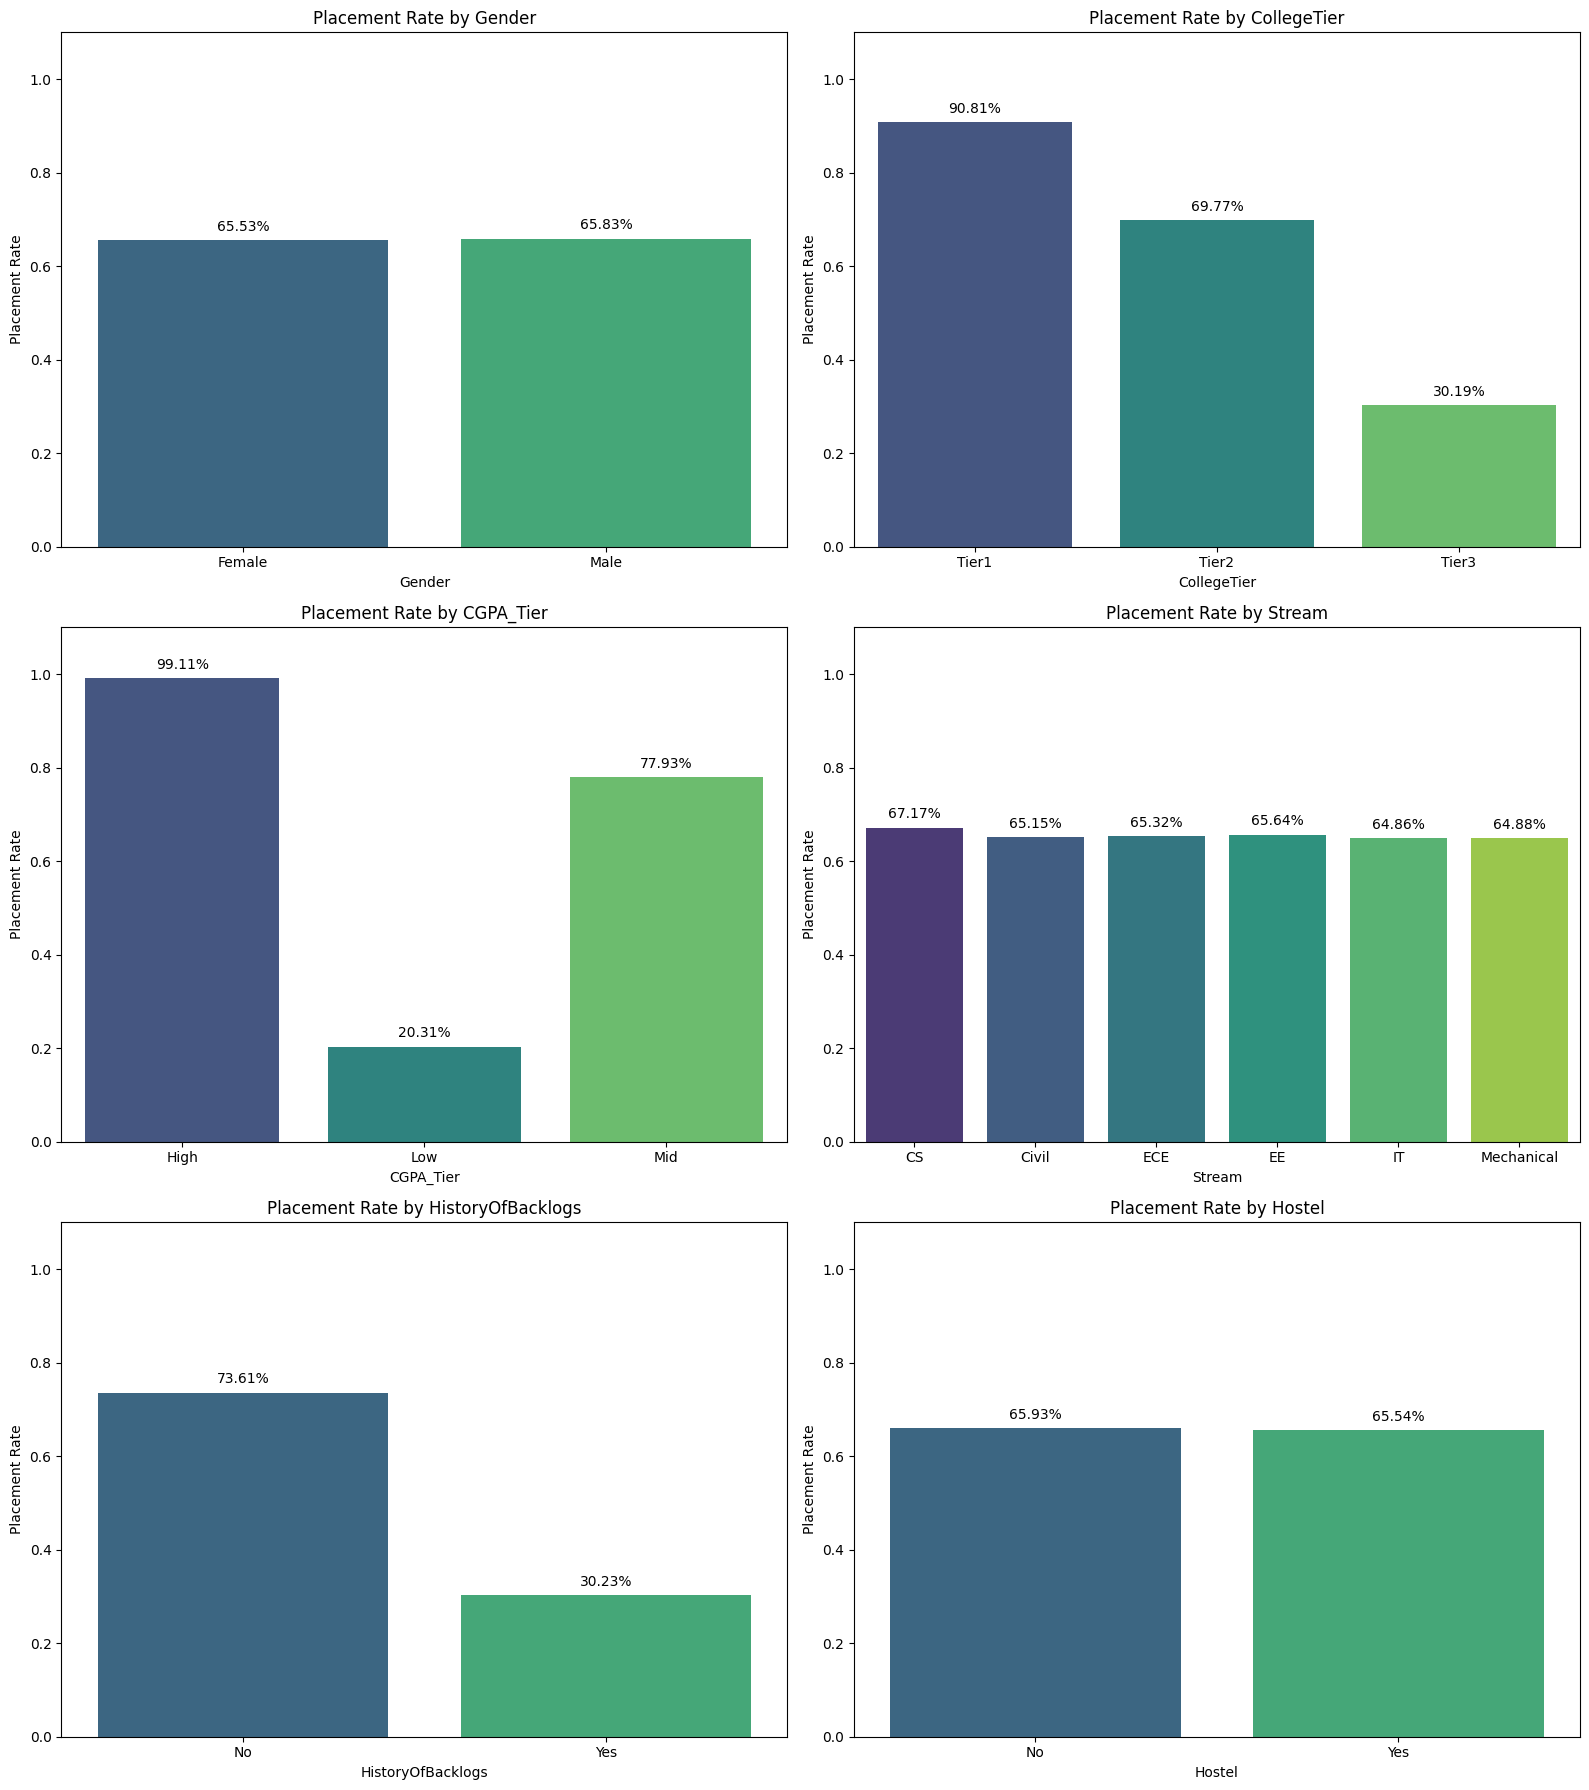

In [48]:
categorical_cols = ["Gender", "CollegeTier", "CGPA_Tier", "Stream", "HistoryOfBacklogs", "Hostel"]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sub_group = df.groupby(col)["PlacementStatus"].agg(["count", "mean"]).reset_index()
    sub_group.columns = [col, "Total Students", "Placement Rate"]

    sns.barplot(x=col, y="Placement Rate", data=sub_group, ax=axes[idx], hue=col, palette="viridis", legend=False)
    axes[idx].set_title(f"Placement Rate by {col}")
    axes[idx].set_ylim(0, 1.1)
    axes[idx].set_ylabel("Placement Rate")

    for p in axes[idx].patches:
        height = p.get_height()
        axes[idx].text(p.get_x() + p.get_width()/2., height + 0.02, f'{height:.2%}', ha="center")

plt.tight_layout()
plt.show()

### Detailed Exploratory Data Analysis (EDA) Report

#### 1. Data Quality and Preparation
* **Missing Values:** The dataset initially had missing values in `Workshops`, `AptitudeTestScore`, `SoftSkillsRating`, `CodingTestScore`, and `MockInterviewScore`. These were successfully handled using mean imputation to maintain statistical consistency.
* **Feature Scaling:** Scores for Aptitude, Soft Skills, Coding, and Mock Interviews were standardized using Z-scores. This process centered the distributions around zero, making them comparable and ready for machine learning modeling.

#### 2. Univariate Analysis (Distributions)
* **Academic Performance:** CGPA and Attendance percentages show a broad distribution with a slight concentration towards higher scores, indicating a generally high-performing student cohort.
* **Technical & Soft Skills:** After standardization, skills like Coding and Soft Skills show multi-modal distributions, suggesting distinct clusters of students with varying proficiency levels.

#### 3. Bivariate Analysis (Key Drivers of Placement)
Based on the correlation matrix and influence plots, the top predictors for `PlacementStatus` are:
1. **CGPA (0.65):** The strongest indicator; high academic performance is the primary gatekeeper for placement.
2. **Mock Interview Score (0.63):** Highlights that preparation and performance in simulated interviews correlate strongly with real-world success.
3. **Soft Skills & Certifications (0.60):** Demonstrates that well-rounded profiles with verified external skills are preferred by employers.

#### 4. Categorical Insights and Disparities
* **College Tier Impact:** There is a significant "Tier Effect." Tier 1 students have a **90.81%** placement rate, which drops to **30.19%** for Tier 3, suggesting that institutional reputation or campus opportunities vary greatly.
* **The 'Backlog' Penalty:** Having a history of backlogs reduces the placement probability from **73.61%** to **30.23%**.
* **CGPA Tiers:** Students in the 'High' CGPA tier have a near-certain placement rate of **99.11%**, whereas 'Low' tier students face a steep challenge at **20.31%**.
* **Neutral Factors:** Interestingly, **Gender**, **Stream** (CS vs. Mechanical, etc.), and **Hostel** status show almost identical placement rates (~65%), indicating a level of meritocracy across these specific demographics.

#### 5. Outlier Observations
* The boxplots reveal that while successful candidates generally have higher scores across all metrics, there are 'anomalies'—students with lower test scores or CGPAs who still secured placements. This suggests that exceptional performance in one specific area (like a high-impact project or internship) can sometimes compensate for lower scores elsewhere.

## Comprehensive EDA Summary & Findings

### 1. Data Integrity & Missing Values
* **Missing Data Identified:** Five key features had missing values: `Workshops`, `AptitudeTestScore`, `SoftSkillsRating`, `CodingTestScore`, and `MockInterviewScore` (ranging from ~3,000 to ~5,000 missing entries each).
* **Imputation Strategy:** All missing values were successfully imputed using the **Mean** of their respective columns to maintain the statistical distribution of the dataset.

### 2. Feature Distributions & Scaling
* **Symmetry:** Most academic features like `CGPA` and `Attendance` show a relatively normal distribution with some peaks at the higher ends.
* **Standardization:** Scores for Aptitude, Soft Skills, Coding, and Mock Interviews were standardized using **Z-score scaling**. This centered the mean at 0 and scaled the variance to 1, ensuring these features are comparable for future machine learning models.

### 3. Key Drivers of Placement (Correlation Analysis)
Based on the correlation coefficients, the following features have the strongest positive influence on `PlacementStatus`:
1.  **CGPA (0.65):** The single most significant predictor of placement.
2.  **Mock Interview Score (0.63):** Highlights the importance of interview preparation.
3.  **Soft Skills Rating (0.60):** Indicates that communication and interpersonal skills are highly valued.
4.  **Certifications (0.60) & Coding Test Scores (0.59):** Technical validation and testing performance are critical factors.

### 4. Categorical Insights
* **College Tier:** There is a drastic difference in placement rates across tiers. **Tier 1 (90.81%)** and **Tier 2 (69.77%)** significantly outperform **Tier 3 (30.19%)**.
* **CGPA Tier:** Students in the 'High' CGPA bracket have a near-guaranteed placement rate of **99.11%**, compared to only **20.31%** for the 'Low' bracket.
* **History of Backlogs:** Students with no backlogs have a **73.61%** placement rate, which drops sharply to **30.23%** for those with a history of backlogs.
* **Gender & Stream:** Placement rates are remarkably consistent across Genders (~65%) and Academic Streams (CS, IT, ECE, etc., all ranging between 64-67%), suggesting no significant bias in these areas.

### 5. Outlier & Boxplot Observations
* **Placement Success:** Boxplots clearly show that placed students (Status 1) consistently have higher medians and tighter interquartile ranges for CGPA and test scores compared to unplaced students.
* **Anomalies:** Some outliers exist in `CGPA` and `CodingTestScore` where students with lower-than-average scores still secured placements, potentially due to exceptional performance in other specific areas like internships or projects.

## Final Analysis for Manual Notes

### I. Data Preparation Overview
* **Initial State:** The dataset had significant missing values (3k-5k per column) in technical and soft skill scores.
* **Cleaning:** Missing data was filled using the **Mean** to maintain statistical balance.
* **Standardization:** Scores were scaled using **Z-scores** so that technical tests and soft skills could be compared on a level field (mean=0, std=1).

### II. Key Academic Insights
* **CGPA (The Major Driver):** Correlation of **0.65**. Students in the 'High' CGPA tier have a **99.11%** chance of placement.
* **Attendance:** Shows a positive correlation (**0.55**), indicating that consistent participation relates to better placement outcomes.
* **Backlogs:** Having backlogs is a major deterrent, reducing placement rates from **73% down to 30%**.

### III. Skill-Based Findings
* **Mock Interviews (0.63):** This is the second most important factor after CGPA. It shows that behavioral and interview prep is critical.
* **Technical Skills:** Coding test scores (**0.59**) and Certifications (**0.60**) show a strong positive impact, reflecting employer demand for verified skills.
* **Projects/Internships:** Both show strong correlations (~0.53-0.58), proving that practical experience significantly boosts a resume.

### IV. Institutional and Demographic Factors
* **College Tier:** A massive gap exists. Tier 1 (**91%**) vs Tier 3 (**30%**). This suggests institutional resources or reputation play a heavy role.
* **Gender & Stream:** These show **neutral impact** (all ~65% rate). This indicates that the hiring process is relatively meritocratic regarding gender and the specific branch of engineering.
* **Hostel Status:** Has **zero impact** on placement success, with almost identical rates for residents and non-residents.

### V. Summary for Manual Entry
"Placement success is primarily driven by academic excellence (CGPA) and interview readiness (Mock Interviews). Technical certifications and projects are the best secondary supporters. While institutional tier matters greatly, personal demographic factors like gender and academic stream do not negatively bias the outcome."